# Notebook 03 — Flujos de generación con LangGraph

Demostración de los **dos flujos críticos** del PoC (Hipótesis de flujo). El objetivo es *ver qué hace* el grafo paso a paso, no medir (eso es el NB 04).

1. **Flujo RAG conversacional**: `classify → retrieve → generate → cite`
2. **Flujo de generación de acta**: `draft → contrast → detect → finalize` (con detección de contradicciones)

Toda la lógica vive en `src/` y aquí solo la orquestamos y trazamos.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # añade .../M8T1/PoT al path

from src.retriever import Retriever
from src.graphs import build_rag_graph, run_rag, build_acta_graph, run_acta

retriever = Retriever().connect()
print(f"pgvector OK — {retriever.count()} chunks indexados")

pgvector OK — 2793 chunks indexados


## 3.1 Flujo RAG — estructura del grafo

Construimos el grafo y lo dibujamos. El clasificador decide si filtrar por tipo de documento; si se equivoca y la similitud es baja, el nodo `retrieve` reintenta sin filtro (degradación elegante).

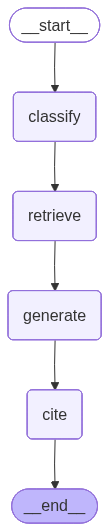

In [4]:
from IPython.display import Image, display

rag_graph = build_rag_graph(retriever, top_k=12)

# Dibuja el grafo (PNG vía mermaid.ink; si no hay red, muestra el texto mermaid)
try:
    display(Image(rag_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_graph.get_graph().draw_mermaid())

## 3.2 Ejecutar el flujo RAG y trazarlo

Helper para mostrar de forma legible qué hizo cada nodo, la respuesta y las fuentes.

In [5]:
def mostrar_rag(state):
    print("PREGUNTA:", state["question"])
    print("\nTRAZA DEL GRAFO:")
    for paso in state["trace"]:
        print("  ·", paso)
    print("\nRESPUESTA:\n" + state["answer"])
    print("\nFUENTES:")
    for c in state["citations"]:
        print("  " + c)

estado = run_rag(rag_graph, "¿Qué grados de tornillos se admiten en uniones de estructuras de acero?")
mostrar_rag(estado)

PREGUNTA: ¿Qué grados de tornillos se admiten en uniones de estructuras de acero?

TRAZA DEL GRAFO:
  · classify → doc_type='normativa'
  · retrieve → 12 chunks (filtro=normativa, 292 ms)
  · generate → respuesta de 234 caracteres
  · cite → 12 fuentes

RESPUESTA:
Se admiten tornillos de grados 8.8 y 10.9 para uniones de estructuras de acero, según la normativa UNE-EN 14399-1. No se utilizarán tornillos de grado inferior a 4.6 o superior a 10.9 sin justificación experimental documentada [1][2].

FUENTES:
  [1] normativa/capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero (p.17) · sim=0.673
  [2] normativa/capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero (p.16) · sim=0.641
  [3] normativa/capitulo_21._fabricacion_y_montaje_de_las_estructuras_de_acero (p.17) · sim=0.583
  [4] normativa/capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero (p.10) · sim=0.573
  [5] normativa/capitulo_18._

### Un ejemplo por cada caso de uso de recuperación

Comprobamos que el enrutado por tipo de documento funciona para normativa, actas, contrato y proyecto.

In [6]:
preguntas_demo = [
    "¿Qué se acordó en las reuniones de obra sobre los plazos de ejecución?",
    "¿Qué obligaciones económicas establece el contrato de obra?",
    "¿Qué combinaciones de acciones se consideran en el cálculo de la estructura?",
]

for q in preguntas_demo:
    estado = run_rag(rag_graph, q)
    mostrar_rag(estado)
    print("\n" + "=" * 80 + "\n")

PREGUNTA: ¿Qué se acordó en las reuniones de obra sobre los plazos de ejecución?

TRAZA DEL GRAFO:
  · classify → doc_type='actas'
  · retrieve → 12 chunks (filtro=actas, 432 ms)
  · generate → respuesta de 249 caracteres
  · cite → 12 fuentes

RESPUESTA:
Se acordó que el plazo de ejecución de la estructura es de 20 semanas y es improrrogable, ya que la inauguración está ligada al calendario pre-electoral del Ayuntamiento. Además, cualquier desviación de plazo deberá justificarse documentalmente [1].

FUENTES:
  [1] actas/Acta_01_S01 (p.2) · sim=0.629
  [2] actas/Acta_01_S01 (p.1) · sim=0.564
  [3] actas/Acta_06_S11 (p.1) · sim=0.546
  [4] actas/Acta_03_S05 (p.1) · sim=0.521
  [5] actas/Acta_04_S07 (p.1) · sim=0.521
  [6] actas/Acta_07_S13 (p.1) · sim=0.521
  [7] actas/Acta_02_S03 (p.1) · sim=0.521
  [8] actas/Acta_01_S01 (p.1) · sim=0.521
  [9] actas/Acta_06_S11 (p.1) · sim=0.521
  [10] actas/Acta_08_S15 (p.1) · sim=0.521
  [11] actas/Acta_05_S09 (p.1) · sim=0.521
  [12] actas/Acta_09

## 3.3 Flujo de generación de acta + detección de contradicciones

A partir de unos puntos de reunión, el grafo redacta el acta, la valida contra la normativa y busca contradicciones con actas anteriores.

In [ ]:
acta_graph = build_acta_graph(retriever)

try:
    display(Image(acta_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(acta_graph.get_graph().draw_mermaid())

In [ ]:
puntos = [
    "Se revisa el control de calidad de la fabricación de las estructuras de acero.",
    "Se acuerda usar tornillos de grado 4.6 para las uniones principales.",
    "Plazo de entrega del montaje: 6 semanas.",
    "Responsable de la inspección: dirección facultativa.",
]

estado_acta = run_acta(acta_graph, puntos)

print("TRAZA DEL GRAFO:")
for paso in estado_acta["trace"]:
    print("  ·", paso)

print("\n" + "=" * 80)
print(estado_acta["acta_final"])

## Resumen

- El **flujo RAG** clasifica, recupera (con fallback sin filtro), genera respuesta fundamentada y cita fuentes.
- El **flujo de acta** redacta, valida contra normativa y detecta contradicciones con actas previas.

Ambos flujos LangGraph se ejecutan en local sin intervención manual → **Hipótesis de flujo** demostrada cualitativamente. La cuantificación (precisión, latencia, consistencia) está en el **NB 04**.